# Simulating of Sonar noise

### 1. Read and visualise real sonar image and simulated example

In [1]:
import torch
import numpy as np
import cv2
import matplotlib.pyplot as plt

In [20]:
def visu(I1, I2, title1=" ", title2=" ", style='gray'):
    fig, ax = plt.subplots(1, 2, figsize=(10, 5))

    ax[0].imshow(I1, cmap=style)
    ax[0].set_title(title1)
    ax[0].axis('off') 
    
    ax[1].imshow(I2, cmap=style)
    ax[1].set_title(title2)
    ax[1].axis('off')  

    plt.tight_layout() 
    plt.show()

(800, 768) (848, 1553)


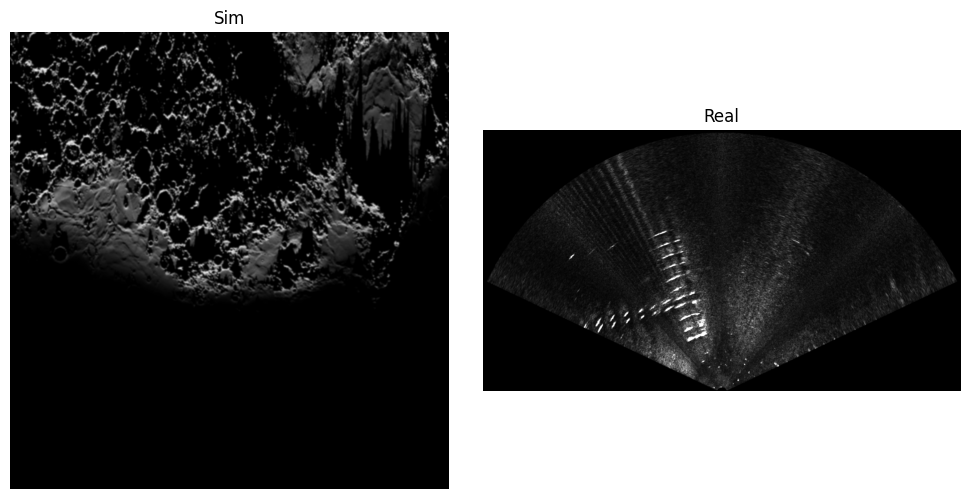

In [26]:
# read an visualise example of simulated sonar image and real sonar image
sim_fls_pth = 'C:/Users/janis/Projekty/Magisterka/SonarOdometry/data/train/seq_1/fls/331.png'
real_fls_pth = 'C:/Users/janis/Projekty/Magisterka/SonarOdometry/data/test/aracati/data_example/4000.png'

I_sim_np = cv2.imread(sim_fls_pth, 0) # 0 - read as grayscale img
I_real_np = cv2.imread(real_fls_pth, 0)
print(I_sim_np.shape, I_real_np.shape)
visu(I_sim_np, I_real_np, title1='Sim', title2='Real')

## Research
According to article **["Speckle Noise Reduction in Sonar Image Based on Adaptive Redundant Dictionary"](https://www.mdpi.com/2077-1312/8/10/761#B29-jmse-08-00761)**, noise in **FLS** Sonar can be modeled as:

$$
y = x * n
$$

where $x$ is orignal Amplitude, $n$ is random noise, generated based on  **Gamma distribution**.



Shape: h = 848, w = 1553
Patch shape: (120, 120)


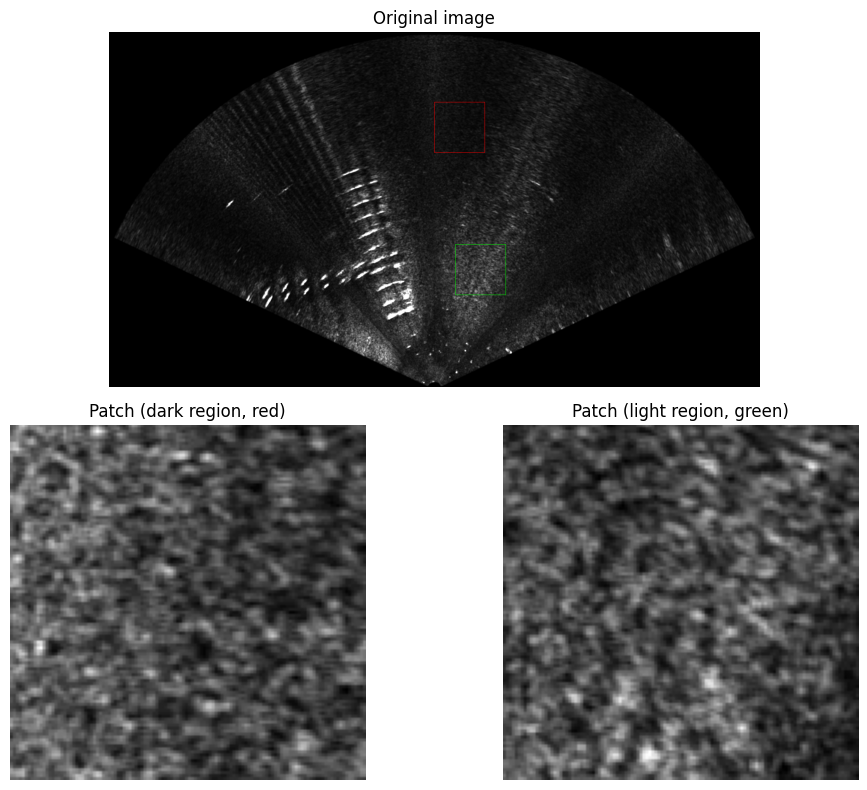

In [37]:
# Get sample of orignal image

h, w = I_real_np.shape
print(f'Shape: h = {h}, w = {w}')

# define upper left corner and box size
corner1 = (h//5, w//2)
corner2 = (3*h//5, w//2+50)
box_h = 120
box_w = 120

# extract patch
patch1 = I_real_np[corner1[0]:corner1[0]+box_h, corner1[1]:corner1[1]+box_w]
patch2 = I_real_np[corner2[0]:corner2[0]+box_h, corner2[1]:corner2[1]+box_w]
print(f'Patch shape: {patch1.shape}')

# mark patch on orginal image
I_real_np_marked = cv2.cvtColor(I_real_np, cv2.COLOR_GRAY2RGB)
I_real_np_marked = cv2.rectangle(I_real_np_marked, (corner1[1], corner1[0]), (corner1[1]+box_w, corner1[0]+box_h), color=(255,0,0))
I_real_np_marked = cv2.rectangle(I_real_np_marked, (corner2[1], corner2[0]), (corner2[1]+box_w, corner2[0]+box_h), color=(0,255,0))

fig, ax = plt.subplot_mosaic([['A', 'A'],
                              ['B', 'C']], figsize=(10, 8))

ax['A'].imshow(I_real_np_marked)
ax['A'].set_title('Original image')
ax['A'].axis('off')

ax['B'].imshow(patch1, cmap='gray')
ax['B'].set_title('Patch (dark region, red)')
ax['B'].axis('off')

ax['C'].imshow(patch2, cmap='gray')
ax['C'].set_title('Patch (light region, green)')
ax['C'].axis('off')

plt.tight_layout()
plt.show()


## Calculate distribution of selected region



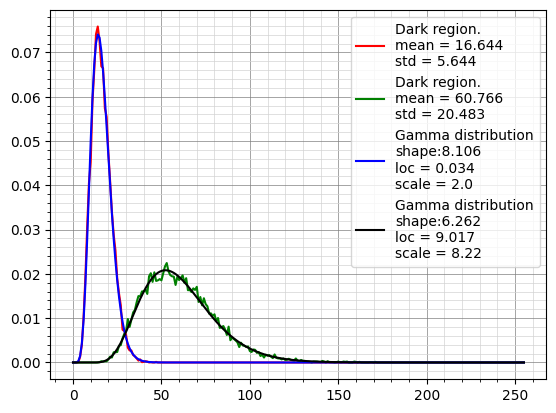

In [88]:
import scipy

h, w = patch1.shape

x_axis = np.linspace(0, 255, 256)

patch1_flat = patch1.flatten()
data1 =  patch1_flat 

patch2_flat = patch2.flatten()
data2 =  patch2_flat 

# ====== Distribution of patches ====== 
histogram1 = scipy.stats.rv_histogram(np.histogram(data1, bins=256, range=(0, 255), density=True))
histogram2 = scipy.stats.rv_histogram(np.histogram(data2, bins=256, range=(0, 255), density=True))

distribution1 = histogram1.pdf(x_axis)
distribution2 = histogram2.pdf(x_axis)

mean1 = histogram1.mean()
std1 = histogram1.std()

mean2 = histogram2.mean()
std2 = histogram2.std()

annotation1 = f'Dark region.\nmean = {mean1:.3f}\nstd = {std1:.3f}'
annotation2 = f'Dark region.\nmean = {mean2:.3f}\nstd = {std2:.3f}'

# ==== Gamma distribution ====

shape1_fit, loc1_fit, scale1_fit = scipy.stats.gamma.fit(data1)
gamma_dist1 = scipy.stats.gamma(a=shape1_fit, loc=loc1_fit, scale=scale1_fit)

# gamma_dist1 = scipy.stats.norm(loc=loc1, scale=scale1)
shape2_fit, loc2_fit, scale2_fit = scipy.stats.gamma.fit(data2)
gamma_dist2 = scipy.stats.gamma(a=shape2_fit, loc=loc2_fit, scale=scale2_fit)


gamma1 = gamma_dist1.pdf(x_axis)
gamma2 = gamma_dist2.pdf(x_axis)

gamma1_annotation = f'Gamma distribution\nshape:{shape1_fit:.3f}\nloc = {loc1_fit:.3f}\nscale = {scale1_fit:.3}'
gamma2_annotation = f'Gamma distribution\nshape:{shape2_fit:.3f}\nloc = {loc2_fit:.3f}\nscale = {scale2_fit:.3}'

fig, ax = plt.subplots()

ax.plot(x_axis, distribution1, 'r-', label = annotation1)
ax.plot(x_axis, distribution2, 'g-', label = annotation2)

ax.plot(x_axis, gamma1, 'b-', label = gamma1_annotation)
ax.plot(x_axis, gamma2, 'k-', label = gamma2_annotation)

ax.grid(which='major', linestyle='-', linewidth='0.5', color='gray', alpha=1)
ax.grid(which='minor', linestyle='-', linewidth='0.5', color='lightgray', alpha=1)
ax.minorticks_on()

ax.legend()

plt.show()